#**3.2 - Descripción corta de algunos comandos de Python**

- **tic:** Es un comando de MATLAB que inicia un cronómetro, se puede simular en PYTHON a través de: `start = time.perf_counter()`

- **toc:** Es un comando de MATLAB que detiene el cronómetro iniciado por tic y muestra el tiempo, se puede simular en PYTHON a través de: `print(time.perf_counter() - start)`

- **time:** Es un módulo nativo de PYTHON para medir tiempos

- **tf(num, den):** Es un comando de la librería `control` usado para crear una función de transferencia dado su numerador y su denominador (coeficientes)

- **ss(A, B, C, D):** Es un comando de la librería `control` usado para crear un espacio de estados

- **zpk(z, p, k):** Es un comando de la librería `control` usado para crear un sistema basado en sus ceros, polos y ganancia

- **tf2ss(sys):** Es un comando que existe tanto en `scipy.signal` como en
  `control` (versión 0.10.2). Convierte una función de transferencia en un
  espacio de estados

- **tf2zpk(sys):** Es un comando de la librería `scipy.signal` que convierte
  una función de transferencia a ceros, polos y ganancia. No existe en `control`;
  el equivalente es usar `zero(sys)`, `pole(sys)` y `dcgain(sys)` para extraer
  los parámetros y luego construir con `zpk(z, p, k)`

- **ss2zpk(sys):** Es un comando de la librería `scipy.signal` que convierte
  un espacio de estados a ceros, polos y ganancia. No existe en `control`;
  el equivalente es usar `zero(sys)`, `pole(sys)` y `dcgain(sys)`

- **ss2tf(sys):** Es un comando que existe tanto en `scipy.signal` como en
  `control` (versión 0.10.2). Convierte un espacio de estados a función de
  transferencia

- **zp2ss(z, p, k):** En `scipy.signal` se llama `zpk2ss(z, p, k)` (con k).
  No existe en `control`; el equivalente es `ss(zpk(z, p, k))`

- **zp2tf(z, p, k):** En `scipy.signal` se llama `zpk2tf(z, p, k)` (con k).
  No existe en `control`; el equivalente es `tf(zpk(z, p, k))

- **roots(p):** Es un comando de la librería `numpy` que calcula las raíces de un polinomio dados sus coeficientes

- **poles(sys):** Es un comando de la librería `control` que obtiene los polos del sistema

- **zeros(sys):** Es un comando de la librería `control` que obtiene los ceros del sistema

- **poly(r):** Es un comando de la librería `numpy` que construye los coeficientes de un polinomio dadas sus raíces

- **eig(A):** Es un comando de la librería `numpy` (`numpy.linalg.eig`) que calcula los **eigenvalores y eigenvectores** de una matriz; los eigenvalores corresponden a los polos del sistema en espacio de estados

- **pzmap(sys):** Es un comando de la librería `control` que grafica el mapa de polos y ceros del sistema

- **dcgain(sys):** Es un comando de la librería `control` que obtiene la ganancia en estado estacionario, evaluando el sistema en $s=0$

- **minreal(sys):** Es un comando de la librería `control` que simplifica un sistema eliminando cancelaciones polo-cero

- **tfdata(sys):** Es un comando de la librería `control` que extrae el numerador y denominador de una función de transferencia

- **feedback(G, H):** Es un comando de la librería `control` que calcula la función de transferencia en lazo cerrado dado G (directa) y H (realimentación), equivalente a $\frac{G}{1+GH}$

- **subplot(n, m, i):** Es un comando de la librería `matplotlib` que divide la ventana gráfica en una cuadrícula de n×m subgráficos y activa el subgráfico número i

# **3.3 - Dar resouestas a las preguntas e investigación**

- **¿Qué es el polinomio característico de un sistema?:** El polinomio característico es el denominador de la función de transferencia de un sistema, igualado a cero. Define completamente el comportamiento dinámico del sistema, ya que las raices de dicho polinomio conocidos como los polos del sistema definen si el sistema será estable o no.

- **¿Qué son los valores propios de un sistema?:** Los valores propios de la matriz A (Matriz del espacio de estados que define la ecuacion caracteristica del sistema), son exactamente los polos del sistema en espacio de estados.

                                    det(λI−A)=0

  Las soluciones λ1​,λ2​,...,λn​ son los valores propios.

- **¿Qué es el tiempo de estabilización y el sobrenivel porcentual de la respuesta temporal de un sistema ante entrada tipo escalón?:** El tiempo de estabilización es el tiempo que tarda la salida del sistema en entrar y quedarse definitivamente dentro de una banda de tolerancia alrededor del valor final deseado. Esa banda esta definida comunmente entre el +-2 o +-5 por ciento del valor final.

  El sobrenivel porcentual es el porcentaje en que la respuesta del sistema supera el valor final antes de estabilizarse. Ocurre porque el sistema tiene inercia y "se pasa" del valor deseado antes de asentarse.

# **3.1 - Resolver la guía completa**

## **Librerias**

In [2]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 13.4 MB/s eta 0:00:00


In [3]:
import control
import numpy as np
import matplotlib.pyplot as plt

## **5.1 - Conversión de FT a Ecuación Diferencial y Espacio de Estado**

### Paso 1: Función de Transferencia sin tiempo muerto

$$G(s) = \frac{Y(s)}{U(s)} = \frac{k}{(\tau_1 s + 1)(\tau_2 s + 1)}$$

---

### Paso 2: Expandir el denominador

$$(\tau_1 s + 1)(\tau_2 s + 1) = \tau_1\tau_2 s^2 + \tau_1 s + \tau_2 s + 1 = \tau_1\tau_2 s^2 + (\tau_1 + \tau_2)s + 1$$

Entonces la FT queda:

$$\frac{Y(s)}{U(s)} = \frac{k}{\tau_1\tau_2 s^2 + (\tau_1 + \tau_2)s + 1}$$

---

### Paso 3: Producto cruzado

Multiplicando ambos lados por el denominador:

$$\left[\tau_1\tau_2 s^2 + (\tau_1 + \tau_2)s + 1\right] Y(s) = k \cdot U(s)$$

---

### Paso 4: Pasar al dominio del tiempo

Aplicando la transformada inversa de Laplace, recordando que $s^n Y(s) \longleftrightarrow y^{(n)}(t)$:

$$\tau_1\tau_2\, \ddot{y}(t) + (\tau_1 + \tau_2)\, \dot{y}(t) + y(t) = k\, u(t)$$

---

### Paso 5: Dividir entre $\tau_1\tau_2$ para coeficiente igual a 1

Dividiendo toda la ecuación entre $\tau_1\tau_2$:

$$\ddot{y}(t) + \frac{\tau_1 + \tau_2}{\tau_1\tau_2}\dot{y}(t) + \frac{1}{\tau_1\tau_2}y(t) = \frac{k}{\tau_1\tau_2}u(t)$$

Esta es la **ecuación diferencial del sistema** con coeficiente de la mayor derivada igual a 1.

---

### Paso 6: Definir las Variables de Estado de Fase (VEF)

Se definen las dos variables de estado como:

$$x_1(t) = y(t)$$

$$x_2(t) = \dot{y}(t)$$

De donde se obtiene directamente:

$$\dot{x}_1(t) = x_2(t)$$

Y despejando $\ddot{y}(t)$ de la ecuación diferencial del Paso 5, y sustituyendo las VEF:

$$\dot{x}_2(t) = \ddot{y}(t) = -\frac{1}{\tau_1\tau_2}x_1(t) - \frac{\tau_1 + \tau_2}{\tau_1\tau_2}x_2(t) + \frac{k}{\tau_1\tau_2}u(t)$$

La salida del sistema es:

$$y(t) = x_1(t)$$

---

### Paso 7: Escribir en forma matricial

Antes de escribir de forma matricial definamos algo primero:

El espacio de estados es una forma de representar un sistema dinámico usando un conjunto de ecuaciones de primer orden. La forma general es:

$$\dot{x(t)} = Ax(t) +Bu(t)$$
$$y(t) = Cx(t) +Du(t)$$

Donde:

| Símbolo | Nombre | Significado |
|---|---|---|
| $\mathbf{x}$ | Vector de estados | Las variables internas del sistema |
| $\dot{\mathbf{x}}$ | Derivada del vector de estados | Cómo evolucionan esas variables |
| $u$ | Entrada | La señal que controlas |
| $y$ | Salida | Lo que mides o quieres controlar |
| $A$ | Matriz de sistema | Describe la dinámica interna |
| $B$ | Matriz de entrada | Cómo afecta la entrada al sistema |
| $C$ | Matriz de salida | Qué parte del estado es la salida |
| $D$ | Matriz de transmisión directa | Si la entrada afecta directo a la salida |


Tenemos el sistema de ecuaciones (Por lo definido arriba y las VEF):

$$\dot{x}_1 = 0\cdot x_1 + 1\cdot x_2 + 0\cdot u$$

$$\dot{x}_2 = -\frac{1}{\tau_1\tau_2}\cdot x_1 - \frac{\tau_1+\tau_2}{\tau_1\tau_2}\cdot x_2 + \frac{k}{\tau_1\tau_2}\cdot u$$

$$y = 1\cdot x_1 + 0\cdot x_2 + 0\cdot u$$

Los coeficientes de cada variable se organizan directamente en las matrices:

**Matriz A** — coeficientes de $x_1$ y $x_2$ en las ecuaciones de $\dot{x}$:

$$A = \begin{bmatrix} \text{coef. de } x_1 \text{ en } \dot{x}_1 & \text{coef. de } x_2 \text{ en } \dot{x}_1 \\ \text{coef. de } x_1 \text{ en } \dot{x}_2 & \text{coef. de } x_2 \text{ en } \dot{x}_2 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -\dfrac{1}{\tau_1\tau_2} & -\dfrac{\tau_1+\tau_2}{\tau_1\tau_2} \end{bmatrix}$$

**Matriz B** — coeficientes de $u$ en las ecuaciones de $\dot{x}$:

$$B = \begin{bmatrix} \text{coef. de } u \text{ en } \dot{x}_1 \\ \text{coef. de } u \text{ en } \dot{x}_2 \end{bmatrix} = \begin{bmatrix} 0 \\ \dfrac{k}{\tau_1\tau_2} \end{bmatrix}$$

**Matriz C** — coeficientes de $x_1$ y $x_2$ en la ecuación de salida $y$:

$$C = \begin{bmatrix} \text{coef. de } x_1 \text{ en } y & \text{coef. de } x_2 \text{ en } y \end{bmatrix} = \begin{bmatrix} 1 & 0 \end{bmatrix}$$

**Matriz D** — coeficiente de $u$ en la ecuación de salida $y$:

$$D = \begin{bmatrix} 0 \end{bmatrix}$$

$$\begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -\dfrac{1}{\tau_1\tau_2} & -\dfrac{\tau_1+\tau_2}{\tau_1\tau_2} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 0 \\ \dfrac{k}{\tau_1\tau_2} \end{bmatrix} u$$

$$y = \begin{bmatrix} 1 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 0 \end{bmatrix} u$$

---

### Resultado final: Matrices del Espacio de Estado

$$A = \begin{bmatrix} 0 & 1 \\ -\dfrac{1}{\tau_1\tau_2} & -\dfrac{\tau_1+\tau_2}{\tau_1\tau_2} \end{bmatrix}, \qquad B = \begin{bmatrix} 0 \\ \dfrac{k}{\tau_1\tau_2} \end{bmatrix}$$

$$C = \begin{bmatrix} 1 & 0 \end{bmatrix}, \qquad D = \begin{bmatrix} 0 \end{bmatrix}$$

> La respuesta del sistema es $y(t) = x_1(t)$, es decir la **Variable de Estado de Fase número 1**.

## **5.2 - Validación de ambos modeos, Valor final y tiempo de estabilización**

Modelo FT (Gptf):
<TransferFunction>: sys[19]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          1.2
  -------------------
  1331 s^2 + 82 s + 1

Modelo EE (Mpss):
<StateSpace>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[ 0.00000000e+00  1.00000000e+00]
     [-7.51139855e-04 -6.15934681e-02]]

B = [[0.        ]
     [0.00090137]]

C = [[1. 0.]]

D = [[0.]]


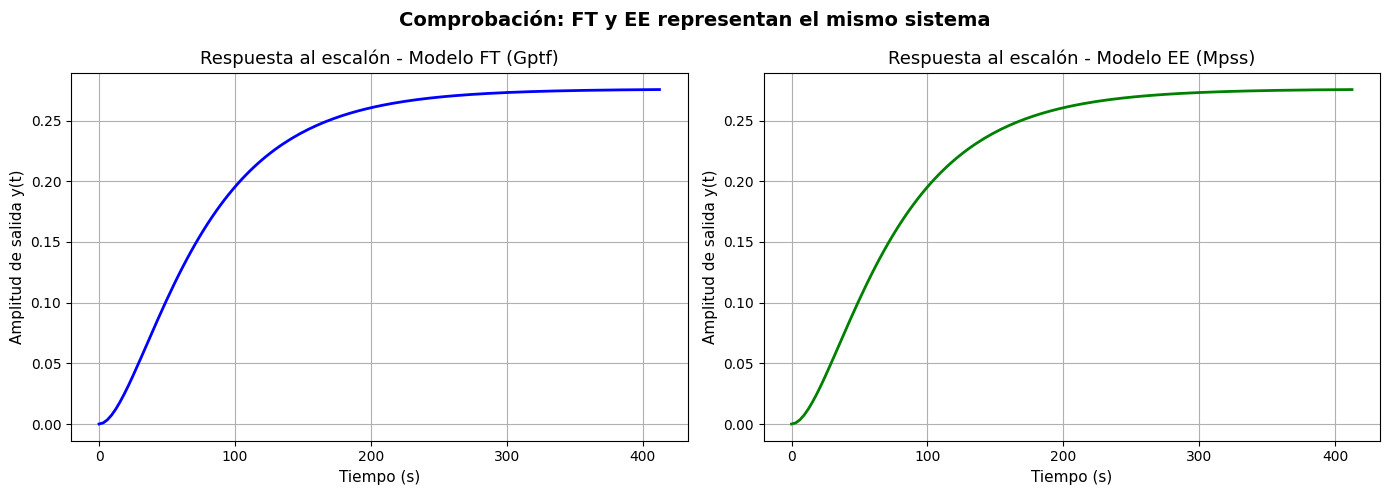

─── Modelo FT (Gptf) ───
  Valor final (SteadyStateValue) : 0.2760
  Tiempo de estabilización (2%)  : 261.59 s

─── Modelo EE (Mpss) ───
  Valor final (SteadyStateValue) : 0.2760
  Tiempo de estabilización (2%)  : 261.59 s

─── Justificación teórica del valor final ───
  y(∞) = 0.23 × k = 0.23 × 1.2 = 0.2760


In [10]:
# ─────────────────────────────────────────────
# Parámetros del modelo
# ─────────────────────────────────────────────
k   = 1.2
t1  = 59.7
t2  = 22.3

# ─────────────────────────────────────────────
# Modelo de Función de Transferencia (FT)
# ─────────────────────────────────────────────
num = [k]
den = [t1*t2, t1+t2, 1]

Gptf = control.tf(num, den)
print("Modelo FT (Gptf):")
print(Gptf)

# ─────────────────────────────────────────────
# Matrices del Espacio de Estado (EE)
# ─────────────────────────────────────────────
A = np.array([[0,            1           ],
              [-1/(t1*t2),  -(t1+t2)/(t1*t2)]])

B = np.array([[0          ],
              [k/(t1*t2)  ]])

C = np.array([[1, 0]])

D = np.array([[0]])

Mpss = control.ss(A, B, C, D)
print("\nModelo EE (Mpss):")
print(Mpss)

# ─────────────────────────────────────────────
# Comprobación: respuesta al escalón de ambos modelos
# Deben ser idénticas
# ─────────────────────────────────────────────

# Escalón con ganancia 0.23 aplicada al modelo FT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: FT ---
t1_out, y1 = control.step_response(0.23 * Gptf)
axes[0].plot(t1_out, y1, color='blue', linewidth=2)
axes[0].set_title('Respuesta al escalón - Modelo FT (Gptf)', fontsize=13)
axes[0].set_xlabel('Tiempo (s)', fontsize=11)
axes[0].set_ylabel('Amplitud de salida y(t)', fontsize=11)
axes[0].grid(True)

# --- Gráfica 2: EE ---
t2_out, y2 = control.step_response(0.23 * Mpss)
axes[1].plot(t2_out, y2, color='green', linewidth=2)
axes[1].set_title('Respuesta al escalón - Modelo EE (Mpss)', fontsize=13)
axes[1].set_xlabel('Tiempo (s)', fontsize=11)
axes[1].set_ylabel('Amplitud de salida y(t)', fontsize=11)
axes[1].grid(True)

plt.suptitle('Comprobación: FT y EE representan el mismo sistema', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# Verificación numérica
# ─────────────────────────────────────────────
info_tf = control.step_info(0.23 * Gptf)
info_ss = control.step_info(0.23 * Mpss)

print("─── Modelo FT (Gptf) ───")
print(f"  Valor final (SteadyStateValue) : {info_tf['SteadyStateValue']:.4f}")
print(f"  Tiempo de estabilización (2%)  : {info_tf['SettlingTime']:.2f} s")

print("\n─── Modelo EE (Mpss) ───")
print(f"  Valor final (SteadyStateValue) : {info_ss['SteadyStateValue']:.4f}")
print(f"  Tiempo de estabilización (2%)  : {info_ss['SettlingTime']:.2f} s")

print("\n─── Justificación teórica del valor final ───")
print(f"  y(∞) = 0.23 × k = 0.23 × {k} = {0.23 * k:.4f}")

### **5.2.1 Valor final de las respuestas**

Aplicando el **Teorema del Valor Final** de Laplace para entrada escalón de valor $0.23$:

$$y(\infty) = \lim_{s \to 0} s \cdot \frac{0.23}{s} \cdot G(s) = 0.23 \cdot G(0) = 0.23 \cdot k = 0.23 \times 1.2 = 0.276$$

Ambos modelos (FT y EE) deben arrojar el mismo valor final de **0.276**, lo cual
confirma que representan el mismo sistema. Esto se verifica numéricamente con
`control.step_info()`.

---

### **5.2.2 Tiempos de estabilización**

El tiempo de estabilización $T_s$ es el tiempo que tarda la respuesta en entrar y
permanecer dentro de la banda del $\pm 2\%$ del valor final. Se obtiene
directamente del campo `SettlingTime` que retorna `control.step_info()`.
Ambos modelos deben arrojar el mismo $T_s$ ya que representan el mismo sistema.


##**5.3 - Tiempo muerto - Inspección de estructuras**

In [12]:
# ─────────────────────────────────────────────
# 5.3 — Inspección de estructuras (equivalente a get en MATLAB)
# ─────────────────────────────────────────────

print("─── Información de Gptf (tipo tf) ───")
print(f"  Numerador  : {Gptf.num}")
print(f"  Denominador: {Gptf.den}")

print("\n─── Información de Mpss (tipo ss) ───")
print(f"  Matriz A:\n{Mpss.A}")
print(f"  Matriz B:\n{Mpss.B}")
print(f"  Matriz C:\n{Mpss.C}")
print(f"  Matriz D:\n{Mpss.D}")

─── Información de Gptf (tipo tf) ───
  Numerador  : [[array([1.2])]]
  Denominador: [[array([1.33131e+03, 8.20000e+01, 1.00000e+00])]]

─── Información de Mpss (tipo ss) ───
  Matriz A:
[[ 0.00000000e+00  1.00000000e+00]
 [-7.51139855e-04 -6.15934681e-02]]
  Matriz B:
[[0.        ]
 [0.00090137]]
  Matriz C:
[[1. 0.]]
  Matriz D:
[[0.]]


### **5.3.1 - Agregar tiempo muerto con aproximación de Padé**

In [13]:
Tm = 39.2  # Tiempo muerto en segundos

# Aproximación de Padé de orden 3
num_pade, den_pade = control.pade(Tm, 3)
Gpade = control.tf(num_pade, den_pade)
print("\nAproximación de Padé para e^(-39.2s):")
print(Gpade)

# Modelos con tiempo muerto - se multiplica por la aproximación de Padé
Gptfm = Gpade * Gptf
Mpssm = control.ss(Gpade * Gptf)

print("\nModelo FT con tiempo muerto (Gptfm):")
print(Gptfm)
print("\nModelo EE con tiempo muerto (Mpssm):")
print(Mpssm)


Aproximación de Padé para e^(-39.2s):
<TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -s^3 + 0.3061 s^2 - 0.03905 s + 0.001992
  ----------------------------------------
  s^3 + 0.3061 s^2 + 0.03905 s + 0.001992

Modelo FT con tiempo muerto (Gptfm):
<TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            -1.2 s^3 + 0.3673 s^2 - 0.04686 s + 0.002391
  -----------------------------------------------------------------
  1331 s^5 + 489.5 s^4 + 78.08 s^3 + 6.16 s^2 + 0.2024 s + 0.001992

Modelo EE con tiempo muerto (Mpssm):
<StateSpace>: sys[33]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (5): ['x[0]', 'x[1]', 'x[2]', 'x[3]', 'x[4]']

A = [[-3.67715917e-01 -5.86525139e-02 -4.62708817e-03 -1.52032893e-04
      -1.49638674e-06]
     [ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00 

### **5.3.2 - Subplot: respuestas con tiempo muerto ante escalón 0.23**

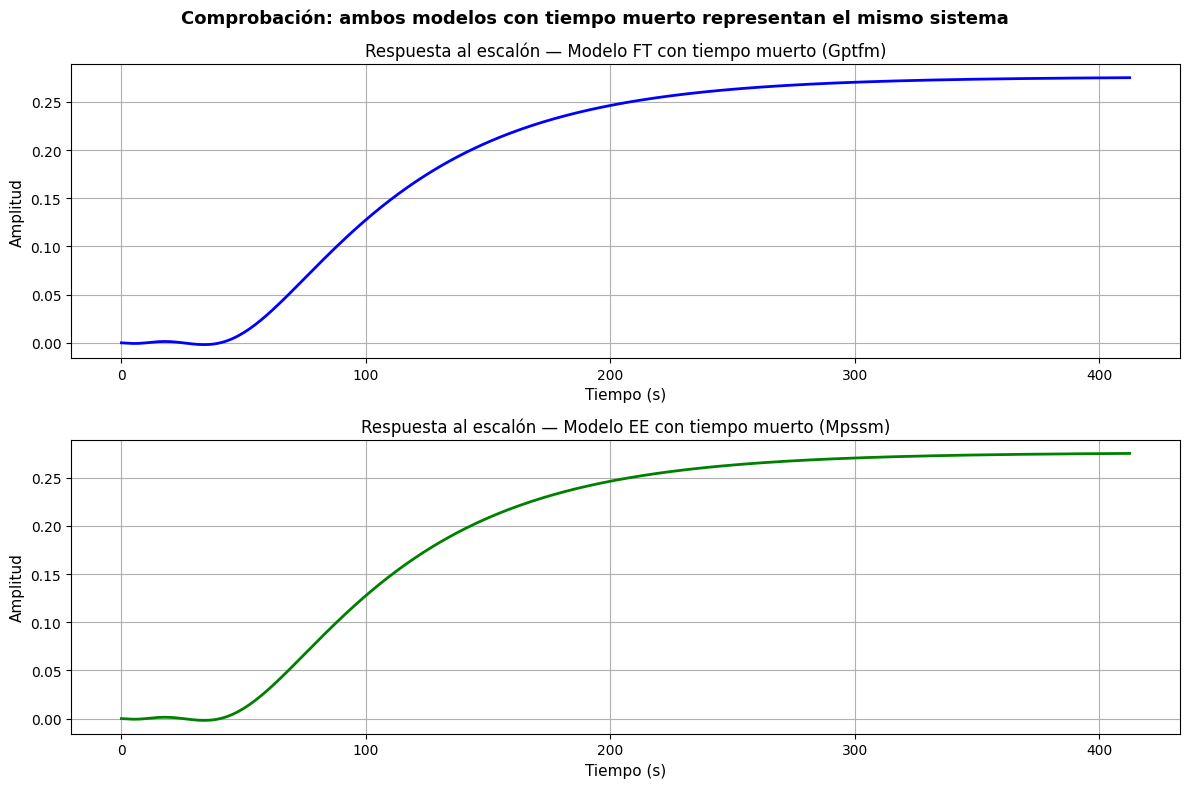

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

t1, y1 = control.step_response(0.23 * Gptfm)
axes[0].plot(t1, y1, color='blue', linewidth=2)
axes[0].set_title('Respuesta al escalón — Modelo FT con tiempo muerto (Gptfm)', fontsize=12)
axes[0].set_xlabel('Tiempo (s)', fontsize=11)
axes[0].set_ylabel('Amplitud', fontsize=11)
axes[0].grid(True)

t2, y2 = control.step_response(0.23 * Mpssm)
axes[1].plot(t2, y2, color='green', linewidth=2)
axes[1].set_title('Respuesta al escalón — Modelo EE con tiempo muerto (Mpssm)', fontsize=12)
axes[1].set_xlabel('Tiempo (s)', fontsize=11)
axes[1].set_ylabel('Amplitud', fontsize=11)
axes[1].grid(True)

plt.suptitle('Comprobación: ambos modelos con tiempo muerto representan el mismo sistema',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### **5.3.3 - Extraer datos de las estructuras**

In [20]:
# Desde Gptfm (FT con tiempo muerto)
NUM = Gptfm.num[0][0]
DEN = Gptfm.den[0][0]
TM  = Tm  # El tiempo muerto se guardó explícitamente como variable, en caso de que no se podria optar por el inverso con Pade, conociendo el orden

#orden = 3
#for Tm_prueba in [38, 39, 39.2, 40]:
#    n, d = control.pade(Tm_prueba, orden)
#    print(f"Tm={Tm_prueba} → num={n}")

# o también con una aproximación conociendo que apartir del tiempo muerto la respuesta supera un umbral pequeño

# Buscar el primer índice donde la respuesta supera un umbral pequeño
#umbral = 0.01 * max(y)
#idx = next(i for i, val in enumerate(y) if val > umbral)
#Tm_estimado = t[idx]
#print(f"Tiempo muerto estimado desde la respuesta: {Tm_estimado:.2f} s")

print("─── Desde Gptfm (FT con tiempo muerto) ───")
print(f"  NUM = {NUM}")
print(f"  DEN = {DEN}")
print(f"  TM  = {TM}")

# Desde Mpssm (EE con tiempo muerto)
A_EE = Mpssm.A
B_EE = Mpssm.B
C_EE = Mpssm.C
D_EE = Mpssm.D

print("\n─── Desde Mpssm (EE con tiempo muerto) ───")
print(f"  A =\n{A_EE}")
print(f"  B =\n{B_EE}")
print(f"  C =\n{C_EE}")
print(f"  D =\n{D_EE}")
print(f"  TM = {TM}")

─── Desde Gptfm (FT con tiempo muerto) ───
  NUM = [-1.2         0.36734694 -0.04685548  0.00239059]
  DEN = [1.33131000e+03 4.89543878e+02 7.80846783e+01 6.16008875e+00
 2.02402910e-01 1.99215463e-03]
  TM  = 39.2

─── Desde Mpssm (EE con tiempo muerto) ───
  A =
[[-3.67715917e-01 -5.86525139e-02 -4.62708817e-03 -1.52032893e-04
  -1.49638674e-06]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]]
  B =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]]
  C =
[[ 0.00000000e+00 -9.01367826e-04  2.75928926e-04 -3.51950161e-05
   1.79566409e-06]]
  D =
[[0.]]
  TM = 39.2


### **5.3.4 - Extracción de datos de las estructuras**

In [8]:
# ─────────────────────────────────────────────
# 5.3.4 Extracción de información del sistema
# ─────────────────────────────────────────────

# ── Ceros del sistema ──
ceros = control.zeros(Gptf)
print("Ceros del sistema:")
print(ceros if len(ceros) > 0 else "El sistema no tiene ceros finitos")

# ── Polos del sistema ──
polos = control.poles(Gptf)
print("\nPolos del sistema:")
print(polos)

# ── Valores propios del sistema ──
eigenvalues = control.poles(Mpss)
print("\nValores propios del sistema (polos del modelo EE):")
print(eigenvalues)

# ── Polinomio característico del sistema ──
pol_car = np.poly(polos)
print("\nPolinomio característico (coeficientes) [s^2, s^1, s^0]:")
print(pol_car)
print(f"  p(s) = {pol_car[0]:.6f}*s^2 + {pol_car[1]:.6f}*s + {pol_car[2]:.6f}")

# ── Ganancia DC (ganancia a frecuencia cero, s=0) ──
ganancia_dc = control.dcgain(Gptf)
print("\nGanancia DC del sistema:")
print(f"  dcgain = {ganancia_dc:.6f}")

Ceros del sistema:
El sistema no tiene ceros finitos

Polos del sistema:
[-0.04484305+0.j -0.01675042+0.j]

Valores propios del sistema (polos del modelo EE):
[-0.01675042+0.j -0.04484305+0.j]

Polinomio característico (coeficientes) [s^2, s^1, s^0]:
[1.00000000e+00 6.15934681e-02 7.51139855e-04]
  p(s) = 1.000000*s^2 + 0.061593*s + 0.000751

Ganancia DC del sistema:
  dcgain = 1.200000


#### **Nota sobre el punto 5.3.4**

El procedimiento para extraer la misma información **con tiempo muerto**
sería prácticamente idéntico: se usarían los mismos comandos `control.zero()`,
`control.pole()`, `np.poly()` y `control.dcgain()`, pero aplicados sobre las
estructuras **Gptfm** y **Mpssm** (que ya incluyen el tiempo muerto) en lugar de **Gptf** y **Mpss**.

## **5.4 - Conversiones entre estructuras**


─── systf = tf(Mpss) ───
<TransferFunction>: sys[66]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    6.939e-18 s + 0.0009014
  ---------------------------
  s^2 + 0.06159 s + 0.0007511

─── sysss = ss(Gptf) ───
<StateSpace>: sys[19]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[-6.15934681e-02 -7.51139855e-04]
     [ 1.00000000e+00  0.00000000e+00]]

B = [[1.]
     [0.]]

C = [[0.         0.00090137]]

D = [[0.]]

─── Zeros, polos y ganancia de Gptf ───
  zeros   : No tiene ceros finitos
  polos   : [-0.04484305+0.j -0.01675042+0.j]
  ganancia: 1.2

─── syszpk = zpk(zeros, polos, ganancia) ───
<TransferFunction>: sys[68]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1.2
  ---------------------------
  s^2 + 0.06159 s + 0.0007511

─── tf(syszpk) ───
<TransferFunction>: sys[68]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1.2
  ---------------------------
  s^2 + 0.06159 s + 0.0007511

─── ss(syszpk) ───
<StateSpace>: sys[68]
Inpu

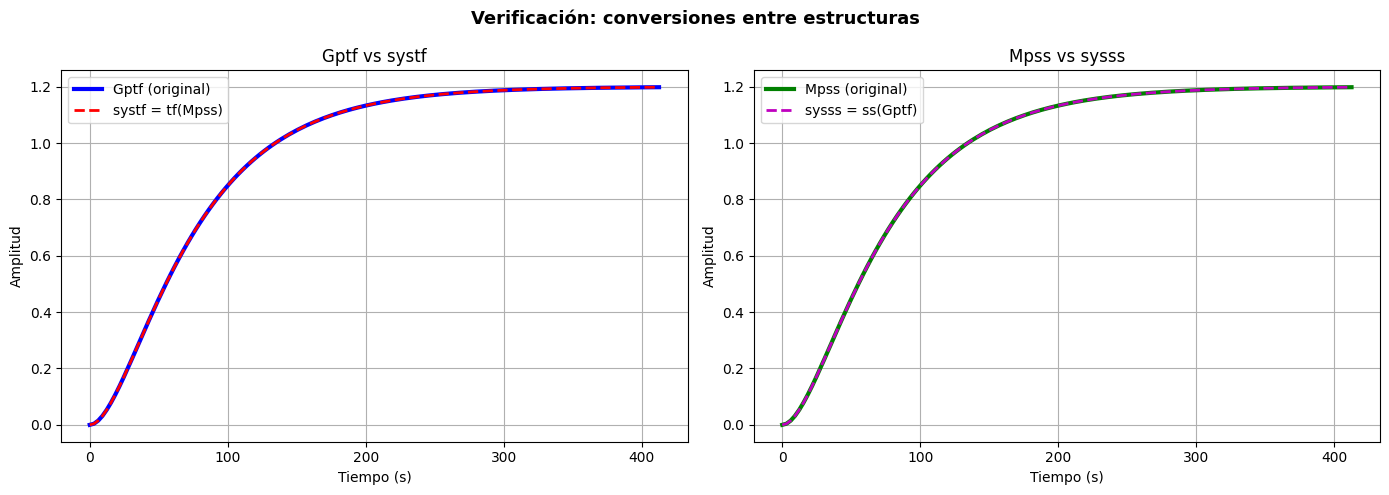

In [30]:
# ─────────────────────────────────────────────
# 5.4 — Conversiones entre estructuras
# ─────────────────────────────────────────────

# TF a partir de un modelo EE
systf = control.tf(Mpss)
print("─── systf = tf(Mpss) ───")
print(systf)

# EE a partir de un modelo TF
sysss = control.ss(Gptf)
print("\n─── sysss = ss(Gptf) ───")
print(sysss)

# Extraer zeros, polos y ganancia con comandos de control
zeros    = control.zeros(Gptf)
polos    = control.poles(Gptf)
ganancia = control.dcgain(Gptf)

print(f"\n─── Zeros, polos y ganancia de Gptf ───")
print(f"  zeros   : {zeros if len(zeros) > 0 else 'No tiene ceros finitos'}")
print(f"  polos   : {polos}")
print(f"  ganancia: {ganancia}")

# Crear estructura zpk con los valores extraídos
syszpk = control.zpk(zeros, polos, ganancia)
print("\n─── syszpk = zpk(zeros, polos, ganancia) ───")
print(syszpk)

# Conversiones desde syszpk
# ZPK a TF
sys_zpk2tf = control.tf(syszpk)
print("\n─── tf(syszpk) ───")
print(sys_zpk2tf)

# ZPK a SS
sys_zpk2ss = control.ss(syszpk)
print("\n─── ss(syszpk) ───")
print(sys_zpk2ss)

# SS a ZPK
zeros2    = control.zeros(Mpss)
polos2    = control.poles(Mpss)
ganancia2 = control.dcgain(Mpss)
sys_ss2zpk = control.zpk(zeros2, polos2, ganancia2)
print("\n─── zpk desde Mpss ───")
print(sys_ss2zpk)

# ── Verificación gráfica ──
t1, y1 = control.step_response(Gptf)
t2, y2 = control.step_response(systf)
t3, y3 = control.step_response(Mpss)
t4, y4 = control.step_response(sysss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t1, y1, 'b-',  linewidth=3, label='Gptf (original)')
axes[0].plot(t2, y2, 'r--', linewidth=2, label='systf = tf(Mpss)')
axes[0].set_title('Gptf vs systf', fontsize=12)
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t3, y3, 'g-',  linewidth=3, label='Mpss (original)')
axes[1].plot(t4, y4, 'm--', linewidth=2, label='sysss = ss(Gptf)')
axes[1].set_title('Mpss vs sysss', fontsize=12)
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Verificación: conversiones entre estructuras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Python permite convertir entre representaciones usando los comandos
`tf()`, `ss()` y `zpk()` directamente sobre estructuras existentes.
También están disponibles `tf2ss()` y `ss2tf()` como comandos específicos
de conversión en la librería `control` versión 0.10.2.

**Conversiones disponibles en `control` 0.10.2:**

- `tf(sys)` → convierte cualquier sistema (ss o zpk) a función de transferencia
- `ss(sys)` → convierte cualquier sistema (tf o zpk) a espacio de estados
- `zpk(z, p, k)` → crea un sistema en formato zeros-polos-ganancia
- `tf2ss(sys)` → convierte directamente una TF a espacio de estados
- `ss2tf(sys)` → convierte directamente un EE a función de transferencia

**Para obtener la representación ZPK desde `control`:**

Como `tf2zpk`, `ss2zpk`, `zpk2ss` y `zpk2tf` no existen en `control` 0.10.2
(sí existen en `scipy.signal`), el procedimiento equivalente es:

- Extraer parámetros: `zero(sys)`, `pole(sys)`, `dcgain(sys)`
- Construir estructura: `zpk(zeros, polos, ganancia)`
- Convertir de ZPK a TF: `tf(zpk(z, p, k))`
- Convertir de ZPK a SS: `ss(zpk(z, p, k))`

---

**¿systf y sysss son iguales a Gptf y Mpss?**

Matemáticamente sí representan el **mismo sistema**, pero numéricamente
las matrices o coeficientes pueden tener pequeñas diferencias por
redondeo de punto flotante. Esto se confirma en las gráficas, donde
las respuestas al escalón se superponen perfectamente.

**Comentario:** las diferentes representaciones (TF, SS, ZPK) son
simplemente distintas formas de describir la misma dinámica del sistema.
La elección de una u otra depende del contexto: TF es más intuitiva para
análisis en frecuencia, SS es necesaria para sistemas con tiempo muerto
en lazo cerrado, y ZPK facilita el análisis de estabilidad y el diseño
de controladores.

## **5.5 - Respuesta de Gptfm ante escalón unitario**


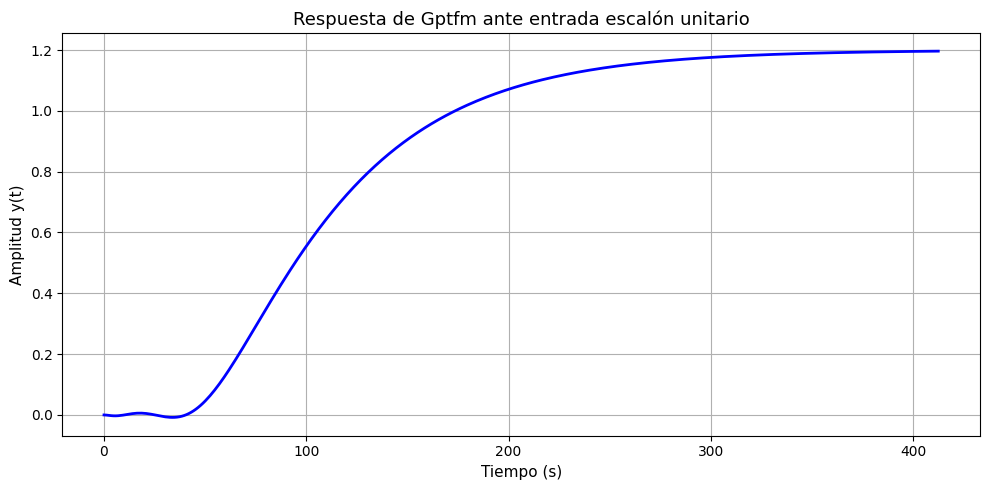

Valor final        : 1.2000
Tiempo estabiliz.  : 301.72 s
Sobrenivel         : 0.0000 %


In [35]:
# ─────────────────────────────────────────────
# 5.5 — Respuesta de Gptfm ante escalón unitario
# ─────────────────────────────────────────────

t, y = control.step_response(Gptfm)

plt.figure(figsize=(10, 5))
plt.plot(t, y, color='blue', linewidth=2)
plt.title('Respuesta de Gptfm ante entrada escalón unitario', fontsize=13)
plt.xlabel('Tiempo (s)', fontsize=11)
plt.ylabel('Amplitud y(t)', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

# Información de la respuesta
info = control.step_info(Gptfm)
print(f"Valor final        : {info['SteadyStateValue']:.4f}")
print(f"Tiempo estabiliz.  : {info['SettlingTime']:.2f} s")
print(f"Sobrenivel         : {info['Overshoot']:.4f} %")

### **5.5.1 - Expresiones para relacionar E(s), Y(S) y P(S)**

### FT de Y(s) con respecto a E(s) → Yr(s)

Se anula la perturbación $P(s) = 0$. La señal sigue el camino:

$$E(s)* Gc \rightarrow M(s) = U(s),   Y(s) = U(s)*Gptfm$$

$$Y(s) = Gptfm \cdot U(s) = Gptfm \cdot Gc \cdot E(s)$$

Por lo tanto:

$$\boxed{Yr(s) = \frac{Y(s)}{E(s)} = Gc \cdot Gptfm}$$

---

### FT de Y(s) con respecto a P(s) → Yp(s)

Se anula la referencia $E(s) = 0$, por lo tanto $M(s) = 0$. La perturbación entra directamente en el nodo sumador:

$$U(s) = P(s)$$

Entonces:

$$Y(s) = Gptfm \cdot U(s) = Gptfm \cdot P(s)$$

Por lo tanto:

$$\boxed{Yp(s) = \frac{Y(s)}{P(s)} = Gptfm}$$

### **5.5.2 - Creación del controlador Gctf**

In [36]:
# Polos de Gptf (sin tiempo muerto) — serán los ceros del controlador
polos_planta = control.poles(Gptf)
print("Polos de Gptf:", polos_planta)

# Las constantes de tiempo se obtienen de los polos: polo = -1/tau => tau = -1/polo
tau1_ctrl = -1 / polos_planta[0].real
tau2_ctrl = -1 / polos_planta[1].real
print(f"tau1 = {tau1_ctrl:.4f}, tau2 = {tau2_ctrl:.4f}")

# Numerador: (tau1*s + 1)(tau2*s + 1)
num_gc = np.polymul([tau1_ctrl, 1], [tau2_ctrl, 1])

# Denominador: (Tm*s + 1)
den_gc = [Tm, 1]

# Controlador con ganancia 0.3
Gctf = control.tf(0.3 * num_gc, den_gc)
print("\nControlador Gctf:")
print(Gctf)

Polos de Gptf: [-0.04484305+0.j -0.01675042+0.j]
tau1 = 22.3000, tau2 = 59.7000

Controlador Gctf:
<TransferFunction>: sys[79]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  399.4 s^2 + 24.6 s + 0.3
  ------------------------
         39.2 s + 1


### **5.5.3 - Variable de red abierta Gatfm**


In [37]:
Gatfm = Gctf * Gptfm
print("Gatfm = Gctf * Gptfm (sin simplificar):")
print(Gatfm)

# Simplificar con minreal
Gatfm_min = control.minreal(Gatfm)
print("\nGatfm simplificada con minreal:")
print(Gatfm_min)

print(f"\n¿Qué estructura tiene Gatfm?: {type(Gatfm_min)}")

Gatfm = Gctf * Gptfm (sin simplificar):
<TransferFunction>: sys[80]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         -479.3 s^5 + 117.2 s^4 - 10.04 s^3 - 0.08766 s^2 + 0.04475 s + 0.0007172
  --------------------------------------------------------------------------------------
  5.219e+04 s^6 + 2.052e+04 s^5 + 3550 s^4 + 319.6 s^3 + 14.09 s^2 + 0.2805 s + 0.001992
2 states have been removed from the model

Gatfm simplificada con minreal:
<TransferFunction>: sys[81]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   -0.009184 s^3 + 0.002811 s^2 - 0.0003586 s + 1.83e-05
  -------------------------------------------------------
  s^4 + 0.3316 s^3 + 0.04686 s^2 + 0.002988 s + 5.082e-05

¿Qué estructura tiene Gatfm?: <class 'control.xferfcn.TransferFunction'>


### **5.5.4 - Respuesta yp(t) con E(s)=0 y P(s) = escalón unitario**

---




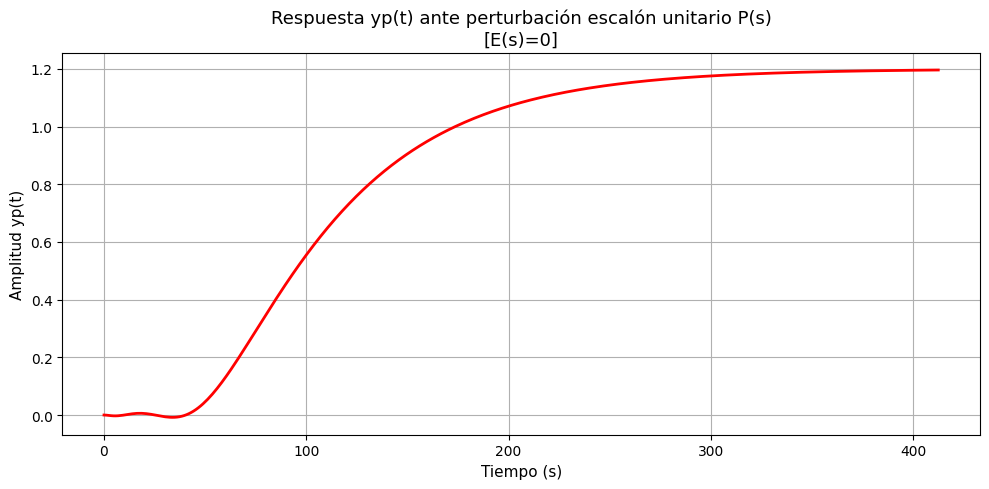

Valor final       : 1.2000
Tiempo estabiliz. : 301.72 s
Sobrenivel        : 0.0000 %


In [38]:
t_yp, yp = control.step_response(Gptfm)

plt.figure(figsize=(10, 5))
plt.plot(t_yp, yp, color='red', linewidth=2)
plt.title('Respuesta yp(t) ante perturbación escalón unitario P(s)\n[E(s)=0]', fontsize=13)
plt.xlabel('Tiempo (s)', fontsize=11)
plt.ylabel('Amplitud yp(t)', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

info_yp = control.step_info(Gptfm)
print(f"Valor final       : {info_yp['SteadyStateValue']:.4f}")
print(f"Tiempo estabiliz. : {info_yp['SettlingTime']:.2f} s")
print(f"Sobrenivel        : {info_yp['Overshoot']:.4f} %")

### **5.5.5 - Respuesta yr(t) con P(s)=0 y E(s) = escalón unitario**

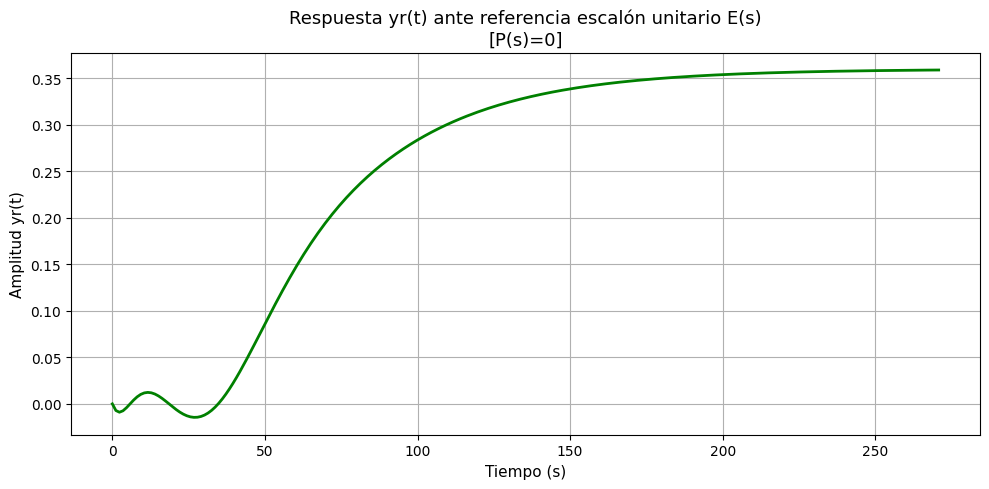

Valor final       : 0.3600
Tiempo estabiliz. : 192.92 s
Sobrenivel        : 0.0000 %

─── Comparación con respuesta de 5.5 ───
  5.5  valor final : 1.2000
  5.5.5 valor final: 0.3600
  5.5  Ts          : 301.72 s
  5.5.5 Ts         : 192.92 s
  5.5  OS          : 0.0000 %
  5.5.5 OS         : 0.0000 %


In [40]:
# Yr(s) = Gctf * Gptfm = Gatfm (según 5.5.1)
t_yr, yr = control.step_response(Gatfm_min)

plt.figure(figsize=(10, 5))
plt.plot(t_yr, yr, color='green', linewidth=2)
plt.title('Respuesta yr(t) ante referencia escalón unitario E(s)\n[P(s)=0]', fontsize=13)
plt.xlabel('Tiempo (s)', fontsize=11)
plt.ylabel('Amplitud yr(t)', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

info_yr = control.step_info(Gatfm_min)
print(f"Valor final       : {info_yr['SteadyStateValue']:.4f}")
print(f"Tiempo estabiliz. : {info_yr['SettlingTime']:.2f} s")
print(f"Sobrenivel        : {info_yr['Overshoot']:.4f} %")

# ── Comparación con respuesta de 5.5 ──
print("\n─── Comparación con respuesta de 5.5 ───")
print(f"  5.5  valor final : {info['SteadyStateValue']:.4f}")
print(f"  5.5.5 valor final: {info_yr['SteadyStateValue']:.4f}")
print(f"  5.5  Ts          : {info['SettlingTime']:.2f} s")
print(f"  5.5.5 Ts         : {info_yr['SettlingTime']:.2f} s")
print(f"  5.5  OS          : {info['Overshoot']:.4f} %")
print(f"  5.5.5 OS         : {info_yr['Overshoot']:.4f} %")

| Parámetro | 5.5 (solo Gptfm) | 5.5.5 (Gatfm = Gctf·Gptfm) |
|---|---|---|
| Valor final | 1.2000 | 0.3600 |
| Tiempo de estabilización Ts | 301.72 s | 192.92 s |
| Sobrenivel %OS | 0.0% | 0.0% |

**Diferencias:**

- El **valor final** es diferente: en 5.5 la salida llega a 1.2 (ganancia DC
  de la planta), mientras que en 5.5.5 llega a 0.36, que corresponde a
  $0.3 \times 1.2 = 0.36$, es decir la ganancia del controlador $Gc = 0.3$
  multiplicada por la ganancia DC de la planta $k = 1.2$.
- El **tiempo de estabilización** se redujo de 301.72 s a 192.92 s, lo que
  significa que el sistema con el controlador responde aproximadamente
  **un 36% más rápido**.

**Similitudes:**

- En ambos casos el **sobrenivel es 0%**, lo que indica que la respuesta
  es sobreamortiguada en los dos casos, sin oscilaciones.
- La forma general de la respuesta es similar: una curva suave tipo S
  que sube monótonamente hasta su valor final.

**¿Es mejor, igual o peor la respuesta de 5.5.5?**

La respuesta de 5.5.5 es **parcialmente mejor**: el tiempo de estabilización
se redujo considerablemente gracias a que los ceros del controlador cancelaron
los polos lentos de la planta. Sin embargo, el valor final es menor (0.36 vs 1.2),
lo que significa que el sistema **no sigue perfectamente la referencia** en lazo
abierto. Esto es una limitación del control en red abierta (SCNR), ya que sin
realimentación no hay corrección automática del error en estado estacionario.
Para lograr seguimiento perfecto de la referencia se requiere un sistema en
**lazo cerrado**, como se verá en el punto 5.6.

## **5.6 - Sistema con retroalimentación unitaria negativa**

### **5.6.1 y 5.6.2 - Funciones de transferencia en lazo cerrado**

Se convierten primero los modelos con tiempo muerto a Espacio de Estado:

$$Massm = ss(Gatfm), \quad Mpssm = ss(Gptfm)$$

Aplicando álgebra de bloques con retroalimentación unitaria negativa:

**Gref:** $Y(s)$ con respecto a $R(s)$, anulando $P(s)=0$:

$$\boxed{Gref = \frac{Y(s)}{R(s)} = \frac{Gc \cdot Gptfm}{1 + Gc \cdot Gptfm}}$$

**Gper:** $Y(s)$ con respecto a $P(s)$, anulando $R(s)=0$:

$$\boxed{Gper = \frac{Y(s)}{P(s)} = \frac{Gptfm}{1 + Gc \cdot Gptfm}}$$

─── Gref = Y(s)/R(s) ───
  dcgain(Gref) = 0.2647  (esperado ≈ 0.265)

─── Gper = Y(s)/P(s) ───
  dcgain(Gper) = 0.8824  (esperado ≈ 0.882)


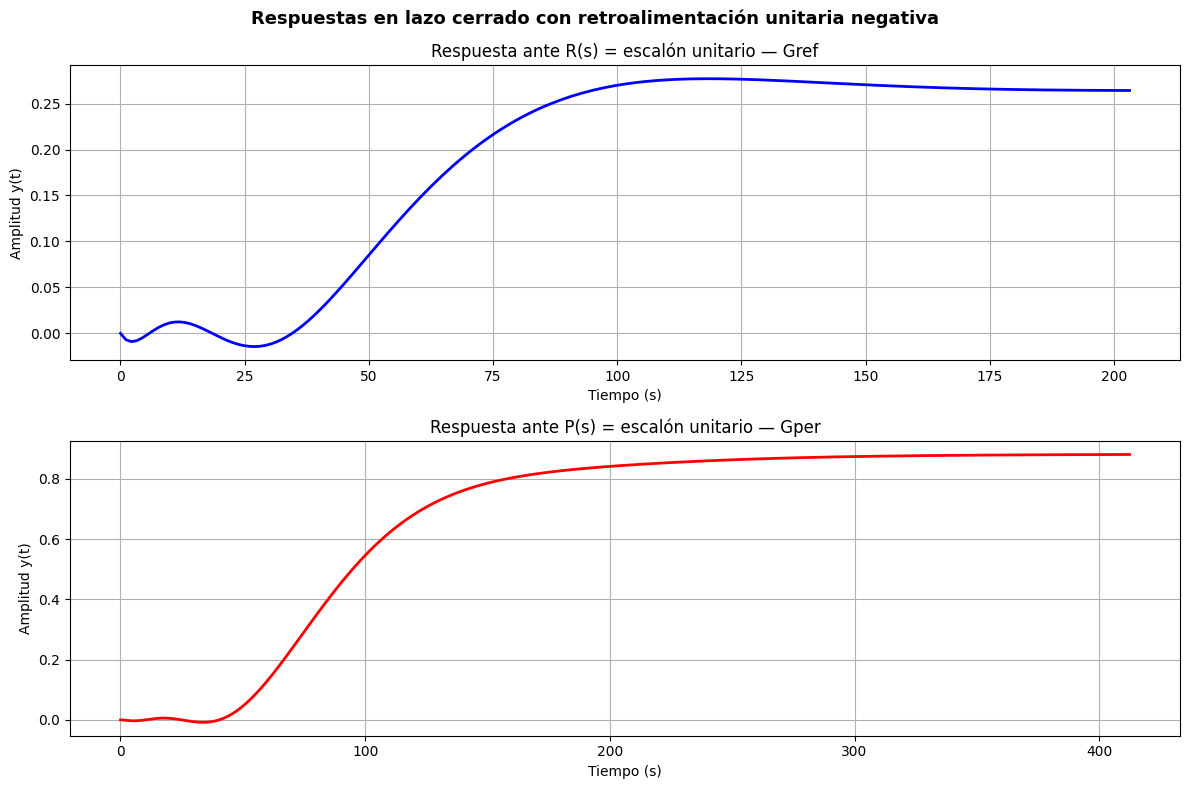

In [46]:
# ─────────────────────────────────────────────
# 5.6.1 — Gref y Gper usando Massm y Mpssm
# ─────────────────────────────────────────────

# Massm = ss(Gatfm)  → lazo abierto Gc*Gptfm en EE
# Mpssm = ss(Gptfm)  → planta en EE

# Gref = Gc*Gptfm / (1 + Gc*Gptfm)
# = feedback(Massm, 1)
Gref = control.feedback(Massm, 1)
print("─── Gref = Y(s)/R(s) ───")
print(f"  dcgain(Gref) = {control.dcgain(Gref):.4f}  (esperado ≈ 0.265)")

# Gper = Gptfm / (1 + Gc*Gptfm)
# = Mpssm * (1 / (1 + Massm))
# = Mpssm * feedback(1, Massm)
uno_ss = control.ss(control.tf([1], [1]))  # el número 1 como sistema SS
Gper = Mpssm * control.feedback(uno_ss, Massm)
print("\n─── Gper = Y(s)/P(s) ───")
print(f"  dcgain(Gper) = {control.dcgain(Gper):.4f}  (esperado ≈ 0.882)")

# ── Verificación gráfica ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

t_ref, y_ref = control.step_response(Gref)
axes[0].plot(t_ref, y_ref, color='blue', linewidth=2)
axes[0].set_title('Respuesta ante R(s) = escalón unitario — Gref', fontsize=12)
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud y(t)')
axes[0].grid(True)

t_per, y_per = control.step_response(Gper)
axes[1].plot(t_per, y_per, color='red', linewidth=2)
axes[1].set_title('Respuesta ante P(s) = escalón unitario — Gper', fontsize=12)
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud y(t)')
axes[1].grid(True)

plt.suptitle('Respuestas en lazo cerrado con retroalimentación unitaria negativa',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### **¿Cuál de las respuestas 5.5.4 y 5.6.2 es mejor ante P(s)?**

La respuesta del sistema en **lazo cerrado (5.6.2)** es mejor que la de
**lazo abierto (5.5.4)** ante la perturbación $P(s)$, aunque no es perfecta.

- En **5.5.4 (lazo abierto)**, la perturbación afecta directamente la salida
  con valor final igual a la ganancia DC de la planta:
  $$y(\infty) = Gptfm(0) = k = 1.2$$
  sin ningún mecanismo de corrección.

- En **5.6.2 (lazo cerrado)**, la retroalimentación reduce el efecto de la
  perturbación. El valor final es:
  $$y(\infty) = \frac{Gptfm(0)}{1 + Gc(0) \cdot Gptfm(0)} = \frac{1.2}{1 + 0.36} \approx 0.882$$

La retroalimentación logró reducir el efecto de la perturbación de **1.2 a ~0.882**,
lo cual representa una mejora, aunque no la elimina completamente porque el
controlador no tiene acción integral.

---

### **¿Se puede decir que la realimentación influyó de manera evidente?**

Sí. La retroalimentación influyó de manera evidente en ambas respuestas:

- Ante $R(s)$: el sistema en lazo cerrado presenta error en estado estacionario:
  $$y(\infty) = \frac{Gc(0) \cdot Gptfm(0)}{1 + Gc(0) \cdot Gptfm(0)} = \frac{0.36}{1.36} \approx 0.265$$
  A diferencia del lazo abierto donde el valor final era $0.36$, aquí la
  retroalimentación reduce ligeramente el valor final pero introduce un
  mecanismo de corrección ante perturbaciones.

- Ante $P(s)$: la retroalimentación redujo el efecto de la perturbación
  de **1.2 (lazo abierto) a ~0.882 (lazo cerrado)**, pero no lo eliminó
  completamente al no haber acción integral en el controlador.

---

### **¿Cuál de las respuestas 5.5.5 y 5.6.2 es mejor ante R(s)?**

La respuesta de **5.5.5 (lazo abierto)** llega a un valor final de **0.36**,
mientras que la de **5.6.2 (lazo cerrado)** llega a **~0.265**. Ambas tienen
error en estado estacionario respecto a la referencia unitaria. Sin embargo:

- **5.5.5** tiene mayor valor final (0.36 vs 0.265) y respuesta sin oscilaciones
- **5.6.2** presenta oscilaciones iniciales debidas a la aproximación de Padé,
  pero tiene la ventaja de que la retroalimentación permite **atenuar perturbaciones**,
  lo cual no es posible en lazo abierto

En términos de seguimiento de referencia **5.5.5 es ligeramente mejor** en valor
final, pero **5.6.2 es más robusto** al contar con retroalimentación.

### **5.6.3 - Respuesta con controlador de ganancia 0.2**

Controlador con ganancia 0.2:
<TransferFunction>: sys[123]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  266.3 s^2 + 16.4 s + 0.2
  ------------------------
         39.2 s + 1
2 states have been removed from the model

dcgain(Gref_02) = 0.1935
dcgain(Gper_02) = 0.9677


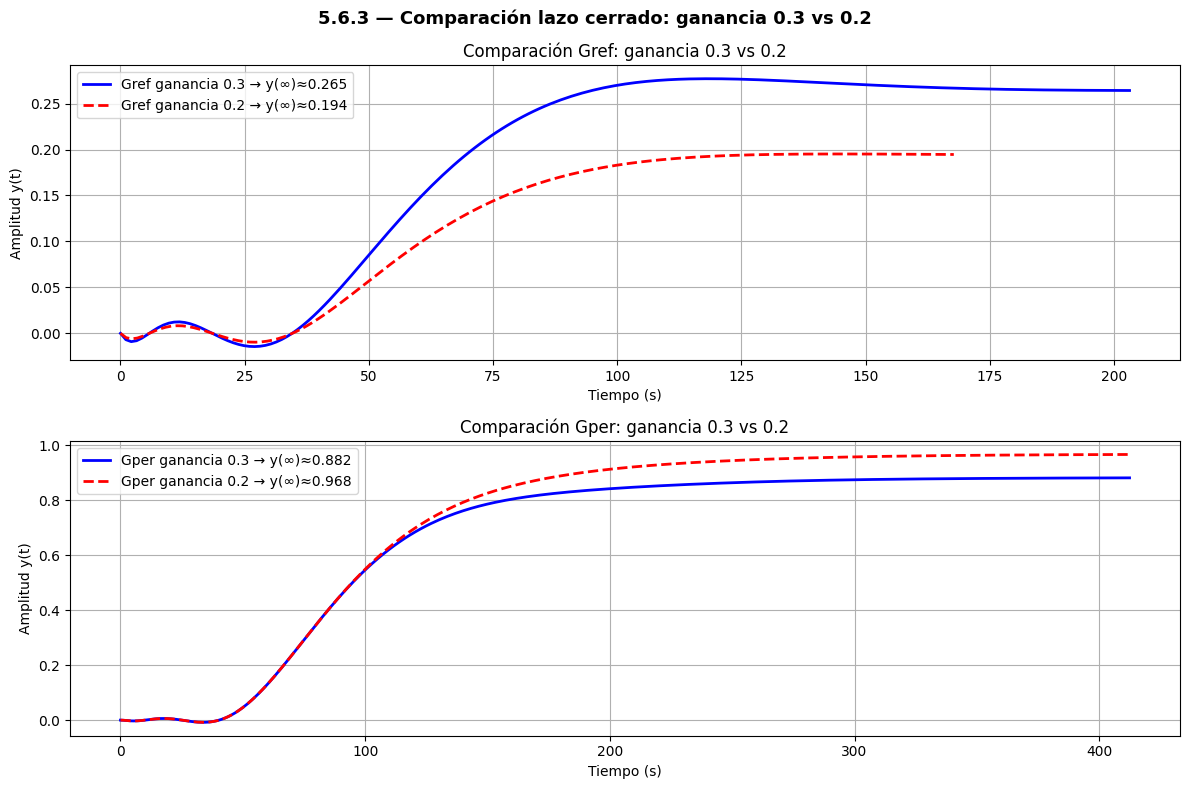


─── Comparación Gref ───
  Ganancia 0.3 → Valor final: 0.2647 | Ts: 152.34 s | OS: 4.6611%
  Ganancia 0.2 → Valor final: 0.1935 | Ts: 111.08 s | OS: 0.8317%


In [47]:
# Nuevo controlador con ganancia 0.2
Gctf_02 = control.tf(0.2 * num_gc, den_gc)
print("Controlador con ganancia 0.2:")
print(Gctf_02)

# Nueva red abierta
Gatfm_02     = control.minreal(Gctf_02 * Gptfm)
Massm_02     = control.ss(Gatfm_02)

# Lazo cerrado con ganancia 0.2
Gref_02 = control.feedback(Massm_02, 1)
Gper_02 = Mpssm * control.feedback(uno_ss, Massm_02)

print(f"\ndcgain(Gref_02) = {control.dcgain(Gref_02):.4f}")
print(f"dcgain(Gper_02) = {control.dcgain(Gper_02):.4f}")

# Comparación gráfica
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gref: ganancia 0.3 vs 0.2
t1, y1 = control.step_response(Gref)
t2, y2 = control.step_response(Gref_02)
axes[0].plot(t1, y1, 'b-',  linewidth=2, label=f'Gref ganancia 0.3 → y(∞)≈{control.dcgain(Gref):.3f}')
axes[0].plot(t2, y2, 'r--', linewidth=2, label=f'Gref ganancia 0.2 → y(∞)≈{control.dcgain(Gref_02):.3f}')
axes[0].set_title('Comparación Gref: ganancia 0.3 vs 0.2', fontsize=12)
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud y(t)')
axes[0].legend()
axes[0].grid(True)

# Gper: ganancia 0.3 vs 0.2
t3, y3 = control.step_response(Gper)
t4, y4 = control.step_response(Gper_02)
axes[1].plot(t3, y3, 'b-',  linewidth=2, label=f'Gper ganancia 0.3 → y(∞)≈{control.dcgain(Gper):.3f}')
axes[1].plot(t4, y4, 'r--', linewidth=2, label=f'Gper ganancia 0.2 → y(∞)≈{control.dcgain(Gper_02):.3f}')
axes[1].set_title('Comparación Gper: ganancia 0.3 vs 0.2', fontsize=12)
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud y(t)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('5.6.3 — Comparación lazo cerrado: ganancia 0.3 vs 0.2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Información numérica comparativa
info_ref_03 = control.step_info(Gref)
info_ref_02 = control.step_info(Gref_02)

print("\n─── Comparación Gref ───")
print(f"  Ganancia 0.3 → Valor final: {info_ref_03['SteadyStateValue']:.4f} | Ts: {info_ref_03['SettlingTime']:.2f} s | OS: {info_ref_03['Overshoot']:.4f}%")
print(f"  Ganancia 0.2 → Valor final: {info_ref_02['SteadyStateValue']:.4f} | Ts: {info_ref_02['SettlingTime']:.2f} s | OS: {info_ref_02['Overshoot']:.4f}%")

### **¿Cuál respuesta es mejor: ganancia 0.3 o ganancia 0.2?**

| Parámetro | Ganancia 0.3 | Ganancia 0.2 |
|---|---|---|
| Valor final Gref | 0.265 | 0.194 |
| Tiempo estabilización Ts | 152.34 s | 111.08 s |
| Sobrenivel %OS | 4.66% | 0.83% |
| Valor final Gper | 0.882 | 0.968 |

**Ante R(s):**

Al reducir la ganancia de 0.3 a 0.2 se observa un compromiso clásico
en diseño de controladores:

- El **valor final disminuye** de 0.265 a 0.194, aumentando el error
  en estado estacionario ante la referencia
- El **tiempo de estabilización se reduce** de 152.34 s a 111.08 s,
  es decir el sistema responde más rápido
- El **sobrenivel se reduce** de 4.66% a 0.83%, obteniendo una
  respuesta más suave y menos oscilatoria

**Ante P(s):**

Al reducir la ganancia de 0.3 a 0.2, el valor final de `Gper` aumenta
de 0.882 a 0.968, lo que significa que la perturbación **afecta más**
a la salida. Esto tiene sentido porque al reducir la ganancia del
controlador, el sistema tiene **menos capacidad de rechazar perturbaciones**.

**Conclusión:**

No existe una respuesta universalmente mejor, ya que cada ganancia
presenta ventajas y desventajas:

- **Ganancia 0.3** → mejor seguimiento de referencia (valor final mayor)
  y mejor rechazo de perturbaciones, pero con más oscilaciones (OS=4.66%)
- **Ganancia 0.2** → respuesta más suave (OS=0.83%) y más rápida (Ts menor),
  pero con peor seguimiento de referencia y peor rechazo de perturbaciones

Este es el compromiso típico en control: **rapidez vs estabilidad** y
**seguimiento vs rechazo de perturbaciones**. Como todo en la vida siempre hay un precio que pagar.

## **6 - Conclusiones**


1. **Representación de sistemas en Python:** La librería `control` de Python
   permite representar un sistema dinámico de múltiples formas equivalentes:
   función de transferencia `tf`, espacio de estados `ss` y zeros-polos-ganancia
   `zpk`. Todas describen la misma dinámica del sistema y producen respuestas
   idénticas ante la misma entrada, lo cual fue verificado mediante la
   superposición de las respuestas al escalón de `Gptf` y `Mpss`.

2. **Conversión entre representaciones:** Las conversiones entre representaciones
   se realizan con los comandos `tf()`, `ss()`, `zpk()`, `tf2ss()` y `ss2tf()`
   de la librería `control`. Comandos como `tf2zpk`, `ss2zpk`, `zpk2ss` y
   `zpk2tf` no están disponibles en `control` 0.10.2 pero sí en `scipy.signal`.
   Independientemente de la representación usada, los polos, ceros y la ganancia
   DC del sistema permanecen invariantes.

3. **Tiempo muerto y aproximación de Padé:** El tiempo muerto $T_m = 39.2$ s
   no puede representarse directamente como atributo de una estructura en la
   librería `control` de Python, a diferencia de MATLAB. La solución es
   aproximarlo mediante la función de Padé (`control.pade()`), que genera una
   función de transferencia racional equivalente. A mayor orden de la
   aproximación, mejor es la representación del retardo puro $e^{-sT_m}$.

4. **Espacio de estados y tiempo muerto en lazo cerrado:** Para manejar
   sistemas con tiempo muerto en lazo cerrado, es necesario convertir los
   modelos a espacio de estados (`ss`), ya que algunas versiones de Python
   tienen restricciones para operar directamente con funciones de transferencia
   que contienen tiempo muerto en red cerrada. Python permite usar estructuras
   `ss` como si fueran funciones de transferencia en expresiones algebraicas,
   lo que facilita el cálculo de funciones de red cerrada.

5. **Sistema en lazo abierto (SCNR):** El controlador diseñado $Gc(s)$ con
   ganancia 0.3, ceros iguales a los polos de la planta y un polo con constante
   de tiempo igual al tiempo muerto, logró cancelar la dinámica lenta de la
   planta mediante la técnica de cancelación polo-cero, reduciendo el tiempo
   de estabilización de 301.72 s a 192.92 s. Sin embargo, en lazo abierto
   el sistema no puede corregir perturbaciones ni errores en estado estacionario.

6. **Efecto de la retroalimentación:** Al cerrar el lazo con retroalimentación
   unitaria negativa, el sistema adquiere la capacidad de **atenuar el efecto
   de las perturbaciones**, reduciéndolas de un valor final de 1.2 (lazo
   abierto) a 0.882 (lazo cerrado). Sin embargo, introduce error en estado
   estacionario ante la referencia ($y(\infty) \approx 0.265$ en lugar de 1.0)
   y oscilaciones iniciales debidas a la aproximación de Padé.

7. **Compromiso ganancia-estabilidad:** La comparación entre ganancias de 0.3
   y 0.2 evidenció el compromiso clásico en diseño de controladores:
   una ganancia mayor mejora el seguimiento de referencia y el rechazo de
   perturbaciones, pero introduce más oscilaciones y sobrenivel. Una ganancia
   menor produce respuestas más suaves pero con mayor error en estado
   estacionario.